In [ ]:
# Seasonal Agriculture Performance Analysis Using Data Analytics

## Major Project

This project analyzes agricultural performance across different seasons
using environmental, agricultural, resource utilization and economic data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
import os

print(os.getcwd())

C:\Users\samar


In [7]:
print(os.listdir())

['.anaconda', '.anaconda-desktop', '.bob', '.bobide', '.bobide-shared', '.conda', '.condarc', '.continuum', '.idlerc', '.ipynb_checkpoints', '.ipython', '.junie', '.jupyter', '.mamba', '.python_history', '.vscode', 'ansel', 'AppData', 'Application Data', 'CarData.csv', 'CarDekho_DataAnalytics_casestudy-Copy1.ipynb', 'CarDekho_DataAnalytics_casestudy-Copy2.ipynb', 'CarDekho_DataAnalytics_casestudy.ipynb', 'cardekho_Data_Analytics_case _study.ipynb', 'CarDekho_Data_Analytics_case_study.ipynb', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{a4367073-7cf3-11ef-adb3-a8595f3e65ce}.TM.blf', 'NTUSER.DAT{a4367073-7cf3-11ef-adb3-a8595f3e65ce}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{a4367073-7cf3-11ef-adb3-a8595f3e65ce}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'PyCharmMiscProject', 'PycharmProjec

In [8]:
import os

for root, dirs, files in os.walk(os.path.expanduser("~")):
    if "seasonal_agriculture_performance_dataset.csv" in files:
        print(os.path.join(root, "seasonal_agriculture_performance_dataset.csv"))

C:\Users\samar\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\6EF3E3DB31D7741A6CDBB38C0AFFD948AB89970E\transfers\2026-37\seasonal_agriculture_performance_dataset.csv
C:\Users\samar\Downloads\seasonal_agriculture_performance_dataset.csv


In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Users\samar\Downloads\seasonal_agriculture_performance_dataset.csv")

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,NaN,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [11]:
print("Dataset Columns:")
for i, col in enumerate(df.columns, 1):
    print(i, col)

Dataset Columns:
1 Farm_ID
2 State
3 District
4 Crop
5 Season
6 Farm_Area_Hectares
7 Rainfall_mm
8 Avg_Temperature_C
9 Humidity_pct
10 Sunlight_Hours_Day
11 Soil_pH
12 Soil_Moisture_pct
13 Nitrogen_kg_ha
14 Phosphorus_kg_ha
15 Potassium_kg_ha
16 Irrigation_Method
17 Fertilizer_kg_ha
18 Pesticide_Litre_ha
19 Seed_Quality_Score
20 Yield_Tonnes_Ha
21 Production_Tonnes
22 Market_Price_INR_Tonne
23 Total_Cost_INR
24 Revenue_INR
25 Profit_INR
26 Water_Used_m3
27 Water_Efficiency_t_per_1000m3
28 Disease_Pest_Risk_pct


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       3999 non-null   str    
 3   Crop                           3995 non-null   str    
 4   Season                         3987 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [13]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [14]:
df.describe(include='object')

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,3999,3995,3987,3999
unique,4000,8,10,8,3,4
top,SF10001,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,688,1774,1310


In [15]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

District              1
Crop                  5
Season               13
Rainfall_mm          48
Soil_Moisture_pct    40
Irrigation_Method     1
Yield_Tonnes_Ha      32
dtype: int64


In [16]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percentage
})

missing_table[missing_table['Missing Values'] > 0]

,Missing Values,Percentage
District,1,0.025
Crop,5,0.125
Season,13,0.325
Rainfall_mm,48,1.200
Soil_Moisture_pct,40,1.000
Irrigation_Method,1,0.025
Yield_Tonnes_Ha,32,0.800


In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [18]:
print(df['Season'].unique())

<ArrowStringArray>
['Kharif', 'Rabi', 'Zaid', nan]
Length: 4, dtype: str


In [19]:
print(df['Crop'].unique())

<ArrowStringArray>
[        nan,     'Maize',    'Pulses',      'Rice',     'Wheat',    'Cotton',
    'Chilli', 'Groundnut', 'Sugarcane']
Length: 9, dtype: str


In [22]:
print(df['Irrigation_Method'].value_counts())

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          914
Sprinkler     734
Name: count, dtype: int64


In [23]:
print(df['Irrigation_Method'].value_counts(normalize=True) * 100)


Irrigation_Method
Flood        32.758190
Rainfed      26.031508
Drip         22.855714
Sprinkler    18.354589
Name: proportion, dtype: float64


In [26]:
print(df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False))

Irrigation_Method
Drip         6.624768
Sprinkler    5.188819
Flood        4.897724
Rainfed      4.613182
Name: Yield_Tonnes_Ha, dtype: float64


In [27]:
print(df.groupby('Irrigation_Method')['Profit_INR'].mean().sort_values(ascending=False))

Irrigation_Method
Drip         219550.963895
Sprinkler     91121.079019
Rainfed       79050.365034
Flood         73354.022901
Name: Profit_INR, dtype: float64


In [28]:
data = df.copy()

In [29]:
categorical_columns = data.select_dtypes(include='object').columns

for col in categorical_columns:
    print(col, data[col].isnull().sum())

Farm_ID 0
State 0
District 1
Crop 5
Season 13
Irrigation_Method 1


In [30]:
numerical_columns = data.select_dtypes(include=np.number).columns

for col in numerical_columns:
    print(col, data[col].isnull().sum())

Farm_Area_Hectares 0
Rainfall_mm 48
Avg_Temperature_C 0
Humidity_pct 0
Sunlight_Hours_Day 0
Soil_pH 0
Soil_Moisture_pct 40
Nitrogen_kg_ha 0
Phosphorus_kg_ha 0
Potassium_kg_ha 0
Fertilizer_kg_ha 0
Pesticide_Litre_ha 0
Seed_Quality_Score 0
Yield_Tonnes_Ha 32
Production_Tonnes 0
Market_Price_INR_Tonne 0
Total_Cost_INR 0
Revenue_INR 0
Profit_INR 0
Water_Used_m3 0
Water_Efficiency_t_per_1000m3 0
Disease_Pest_Risk_pct 0


In [31]:
for col in numerical_columns:
    data[col] = data[col].fillna(data[col].median())

In [32]:
for col in categorical_columns:
    data[col] = data[col].fillna(data[col].mode()[0])

In [33]:
print("Total missing values:", data.isnull().sum().sum())

Total missing values: 0


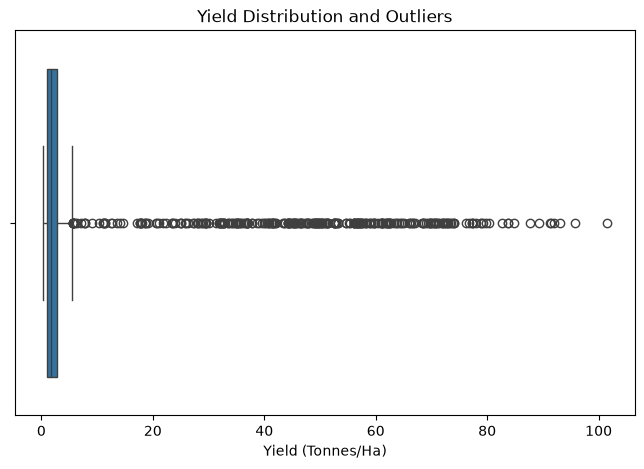

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(x=df['Yield_Tonnes_Ha'])

plt.title("Yield Distribution and Outliers")
plt.xlabel("Yield (Tonnes/Ha)")
plt.show()



In [36]:
df['Yield_Tonnes_Ha']

0       2.46
1       0.30
2       0.52
3       1.84
4       2.21
        ... 
3995    0.51
3996    2.75
3997    0.62
3998    1.35
3999    2.36
Name: Yield_Tonnes_Ha, Length: 4000, dtype: float64

In [37]:
print(df.columns)

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='str')


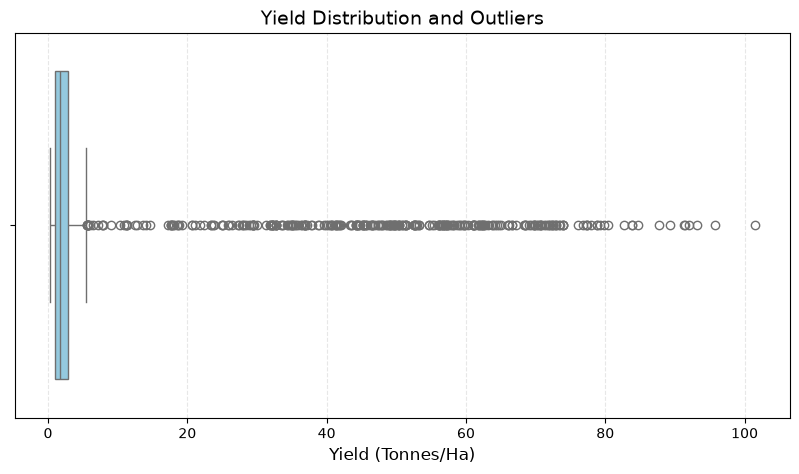

In [38]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df['Yield_Tonnes_Ha'],
    color='skyblue'
)

plt.title("Yield Distribution and Outliers", fontsize=14)
plt.xlabel("Yield (Tonnes/Ha)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

In [39]:
Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df['Yield_Tonnes_Ha'] < lower_limit) |
    (df['Yield_Tonnes_Ha'] > upper_limit)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Outliers:", len(outliers))

Q1: 1.05
Q3: 2.84
IQR: 1.7899999999999998
Lower Limit: -1.6349999999999996
Upper Limit: 5.5249999999999995
Number of Outliers: 302


In [ ]:
# Exploratory Data Analysis

The exploratory data analysis is performed to understand the distribution
of agricultural activities, seasonal patterns, crop performance,
resource utilization and economic outcomes.

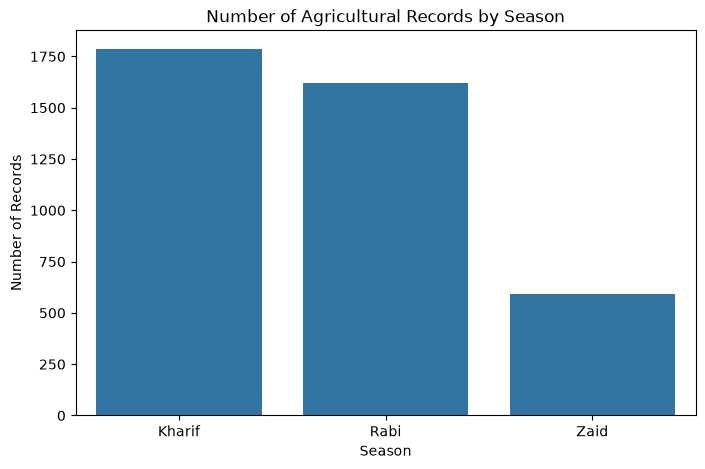

In [41]:
season_count = data['Season'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_count.index,
    y=season_count.values
)

plt.title("Number of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.show()

In [43]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

print(season_yield)

Season
Kharif    5.654137
Rabi      5.054190
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


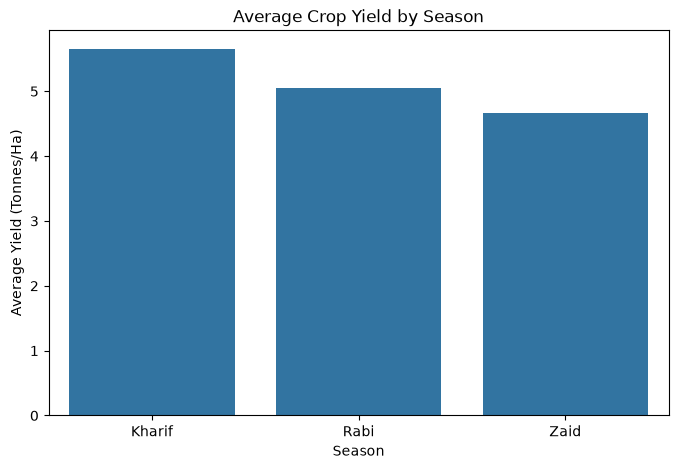

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.show()

In [46]:
season_profit = df.groupby('Season')['Profit_INR'].mean()

print(season_profit)

Season
Kharif    179542.735626
Rabi       87481.985794
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


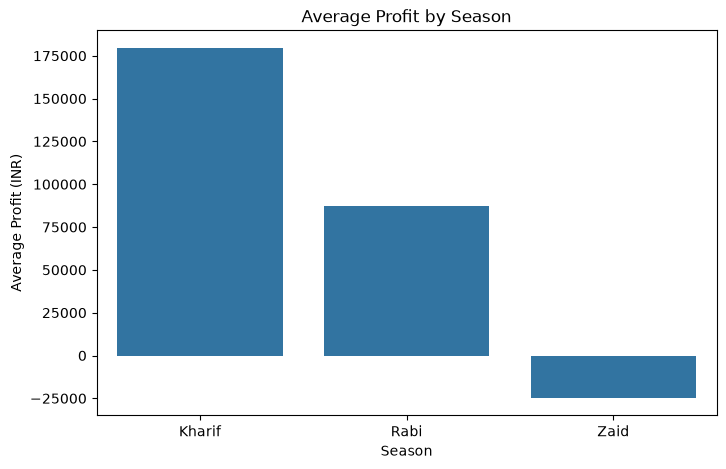

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=season_profit.index,
    y=season_profit.values
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.show()

In [49]:
economic = df.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR']
].mean()

print(economic)

          Revenue_INR  Total_Cost_INR
Season                               
Kharif  711271.837091   531729.101466
Rabi    601301.591106   513819.605312
Zaid    519171.904040   543976.728956


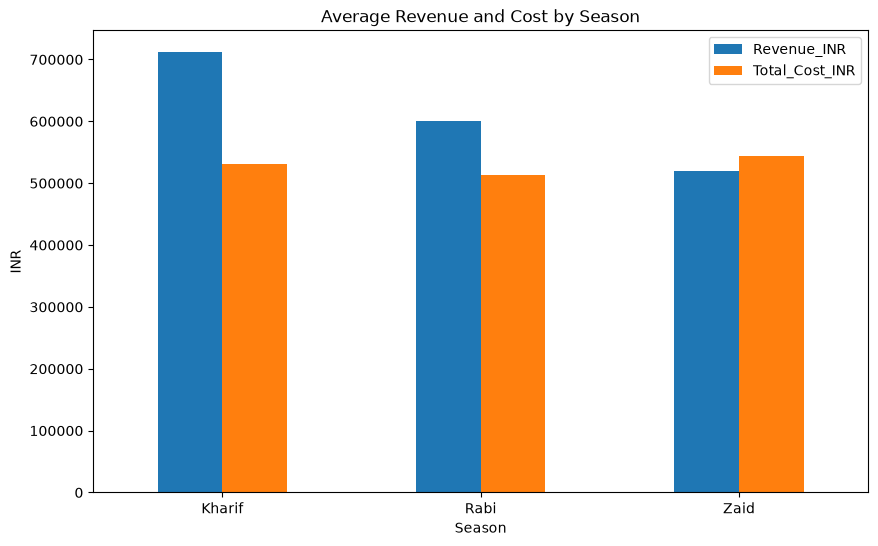

In [50]:
economic.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Average Revenue and Cost by Season")
plt.xlabel("Season")
plt.ylabel("INR")
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [52]:
water = df.groupby('Season')['Water_Used_m3'].mean()

print(water)

Season
Kharif    6105.015784
Rabi      5846.759728
Zaid      6419.893939
Name: Water_Used_m3, dtype: float64


In [53]:
water = (
    df.groupby('Season')['Water_Used_m3']
    .mean()
    .sort_values(ascending=False)
)

print(water)

Season
Zaid      6419.893939
Kharif    6105.015784
Rabi      5846.759728
Name: Water_Used_m3, dtype: float64


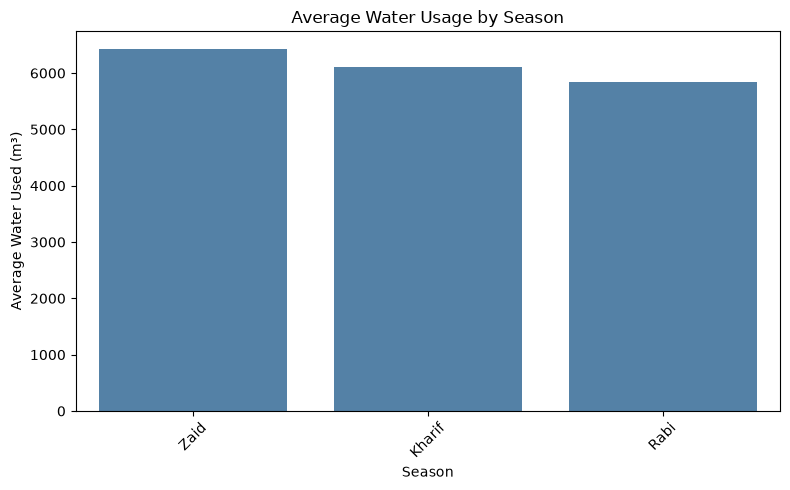

In [54]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=water.index,
    y=water.values,
    color='steelblue'
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [57]:
water_eff = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean()

print(water_eff)

Season
Kharif    5.897324
Rabi      5.163707
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


In [58]:
water_eff = (
    df.groupby('Season')['Water_Efficiency_t_per_1000m3']
    .mean()
    .sort_values(ascending=False)
)

print(water_eff)

Season
Kharif    5.897324
Rabi      5.163707
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


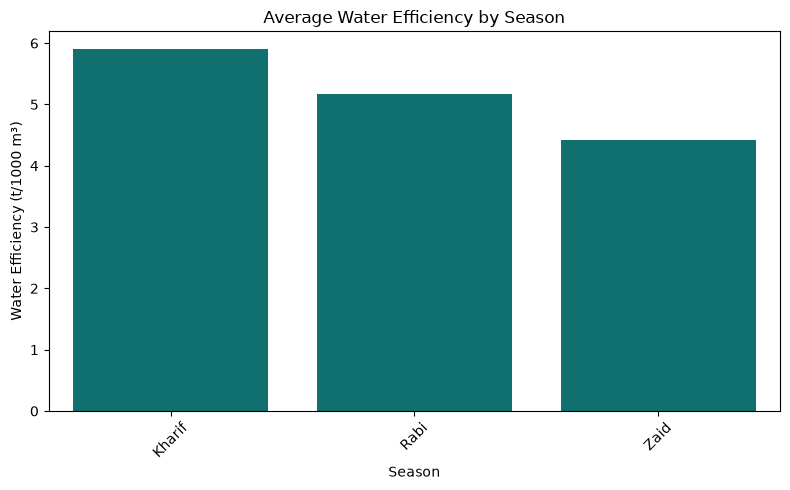

In [59]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=water_eff.index,
    y=water_eff.values,
    color='teal'
)

plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (t/1000 m³)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [61]:
#Crop-wise Analysis
crop_count = data['Crop'].value_counts()

print(crop_count)

Crop
Rice         693
Wheat        613
Maize        551
Cotton       508
Pulses       495
Groundnut    424
Chilli       411
Sugarcane    305
Name: count, dtype: int64


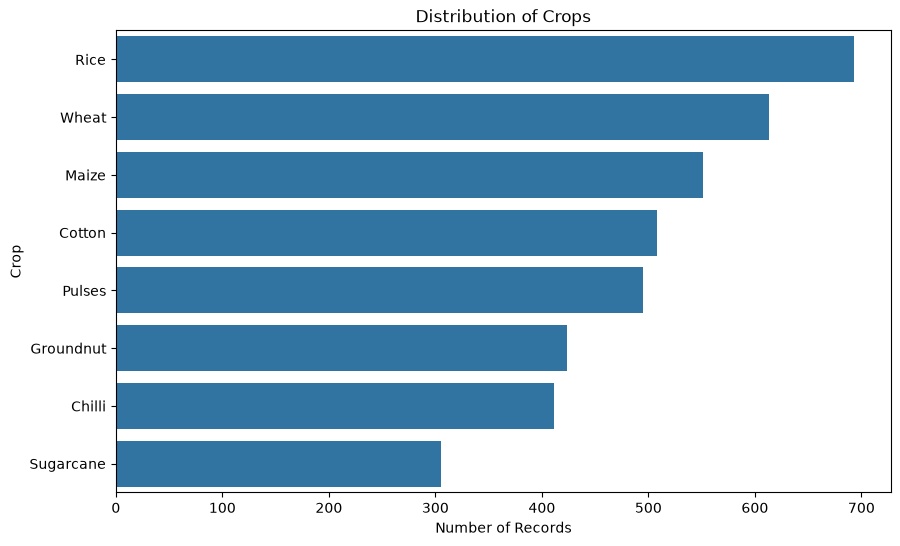

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=crop_count.values,
    y=crop_count.index
)

plt.title("Distribution of Crops")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.show()

In [64]:
# Crop Yield Analysis
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

print(crop_yield)

Crop
Sugarcane    46.938746
Maize         2.717130
Rice          2.443279
Wheat         2.108642
Chilli        1.538990
Groundnut     1.317924
Cotton        1.225734
Pulses        0.917708
Name: Yield_Tonnes_Ha, dtype: float64


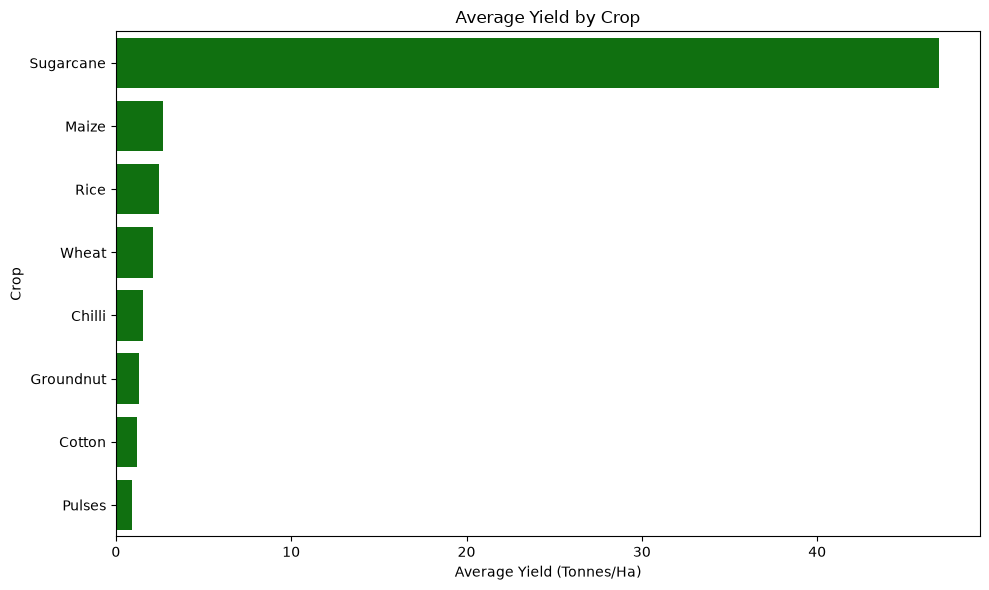

In [65]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_yield.values,
    y=crop_yield.index,
    color='green'
)

plt.title("Average Yield by Crop")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [67]:
# Season + Crop Analysis
season_crop_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

print(season_crop_yield)

Season        Kharif       Rabi       Zaid
Crop                                      
Chilli      1.730383   1.457688   1.177742
Cotton      1.372804   1.192437   0.951648
Groundnut   1.489843   1.221445   1.037778
Maize       2.962618   2.610262   2.297590
Pulses      1.038858   0.872085   0.652131
Rice        2.703806   2.342734   1.900490
Sugarcane  53.459120  44.068480  38.423922
Wheat       2.254724   2.059957   1.748588


In [68]:
season_crop_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
).round(2)

print(season_crop_yield)

Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.46   1.18
Cotton       1.37   1.19   0.95
Groundnut    1.49   1.22   1.04
Maize        2.96   2.61   2.30
Pulses       1.04   0.87   0.65
Rice         2.70   2.34   1.90
Sugarcane   53.46  44.07  38.42
Wheat        2.25   2.06   1.75


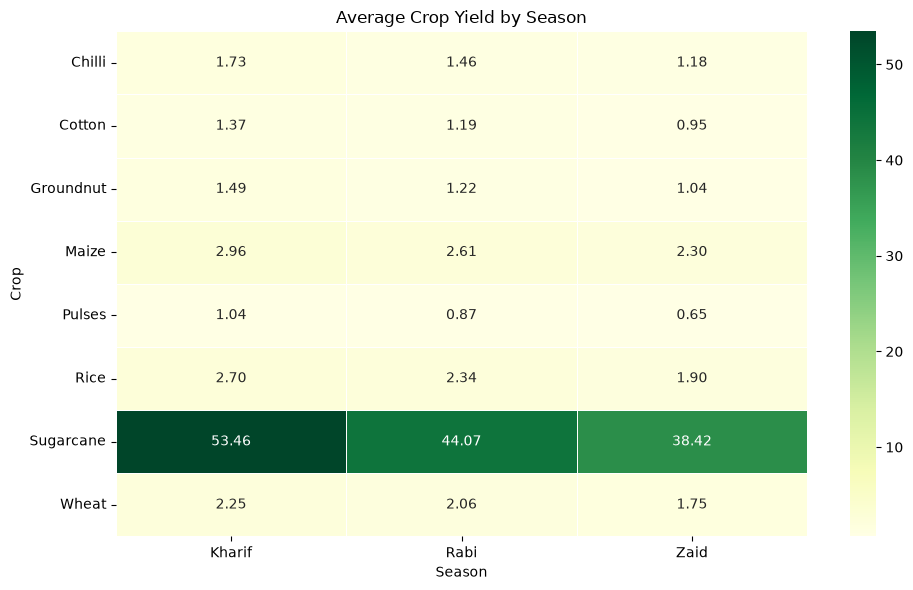

In [69]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    season_crop_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGn",
    linewidths=0.5
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [71]:
# Irrigation Analysis
irrigation_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Irrigation_Method',
    columns='Season',
    aggfunc='mean'
)

print(irrigation_yield)

Season               Kharif      Rabi      Zaid
Irrigation_Method                              
Drip               7.273515  6.230111  5.848143
Flood              5.013339  5.072481  4.031632
Rainfed            5.725261  3.855438  3.063786
Sprinkler          4.673824  5.365451  6.172773


In [72]:
irrigation_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Irrigation_Method',
    columns='Season',
    aggfunc='mean'
).round(2)

print(irrigation_yield)

Season             Kharif  Rabi  Zaid
Irrigation_Method                    
Drip                 7.27  6.23  5.85
Flood                5.01  5.07  4.03
Rainfed              5.73  3.86  3.06
Sprinkler            4.67  5.37  6.17


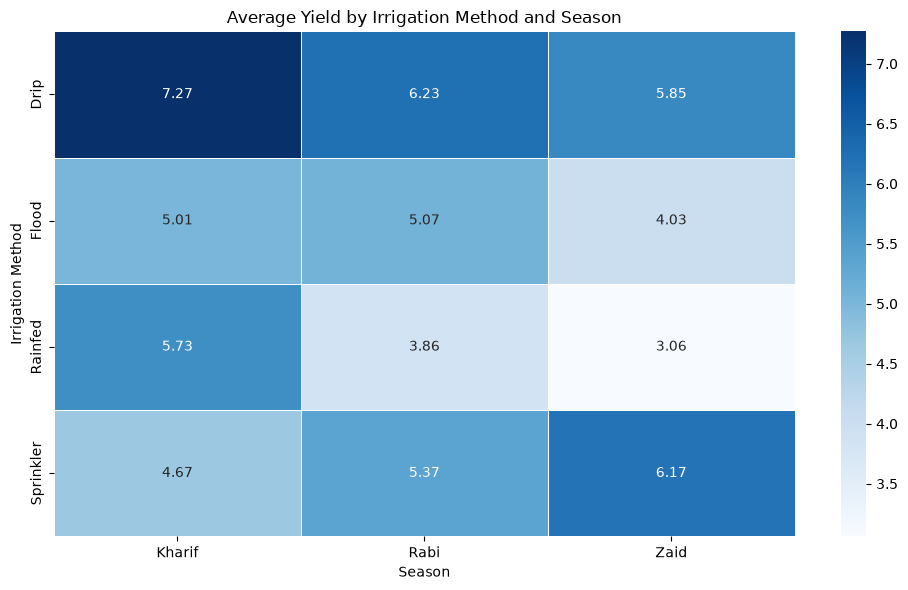

In [73]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    irrigation_yield,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Average Yield by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Irrigation Method")

plt.tight_layout()
plt.show()

In [75]:
# Irrigation vs Profit
irrigation_profit = df.pivot_table(
    values='Profit_INR',
    index='Irrigation_Method',
    columns='Season',
    aggfunc='mean'
)

print(irrigation_profit)

Season                    Kharif           Rabi          Zaid
Irrigation_Method                                            
Drip               318998.836634  187315.676630  21291.835714
Flood              133963.865646   59168.199234 -69786.778351
Rainfed            159324.658009   43472.488532 -79467.257143
Sprinkler          116420.431250   77305.321918  57909.400000


In [76]:
irrigation_profit = df.pivot_table(
    values='Profit_INR',
    index='Irrigation_Method',
    columns='Season',
    aggfunc='mean'
).round(2)

print(irrigation_profit)

Season                Kharif       Rabi      Zaid
Irrigation_Method                                
Drip               318998.84  187315.68  21291.84
Flood              133963.87   59168.20 -69786.78
Rainfed            159324.66   43472.49 -79467.26
Sprinkler          116420.43   77305.32  57909.40


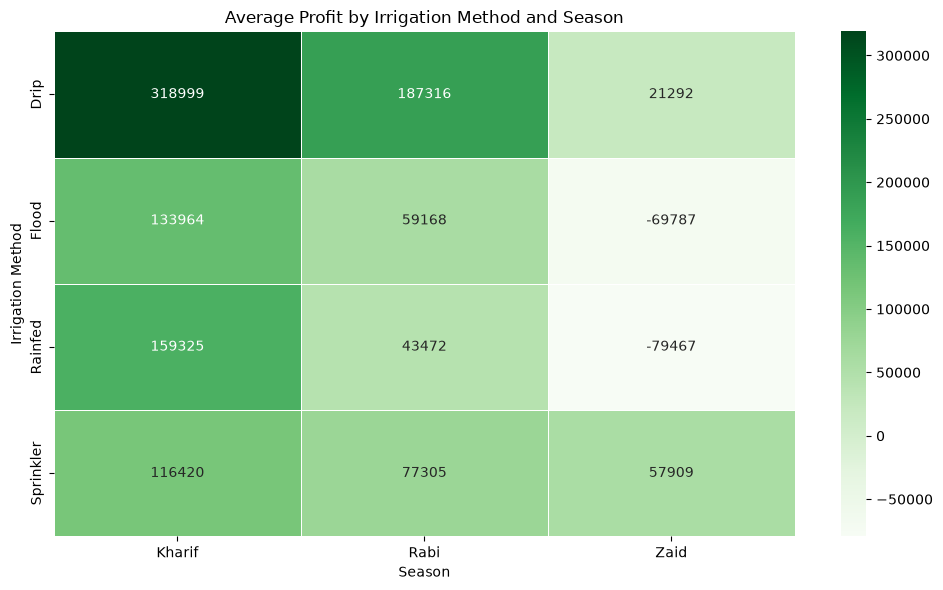

In [77]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    irrigation_profit,
    annot=True,
    fmt=".0f",
    cmap="Greens",
    linewidths=0.5
)

plt.title("Average Profit by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Irrigation Method")

plt.tight_layout()
plt.show()

In [79]:
# Environmental Analysis
rainfall = df.groupby('Season')['Rainfall_mm'].mean()

print(rainfall)

Season
Kharif    852.190883
Rabi      436.190568
Zaid      299.421784
Name: Rainfall_mm, dtype: float64


In [80]:
rainfall = (
    df.groupby('Season')['Rainfall_mm']
    .mean()
    .sort_values(ascending=False)
)

print(rainfall)

Season
Kharif    852.190883
Rabi      436.190568
Zaid      299.421784
Name: Rainfall_mm, dtype: float64


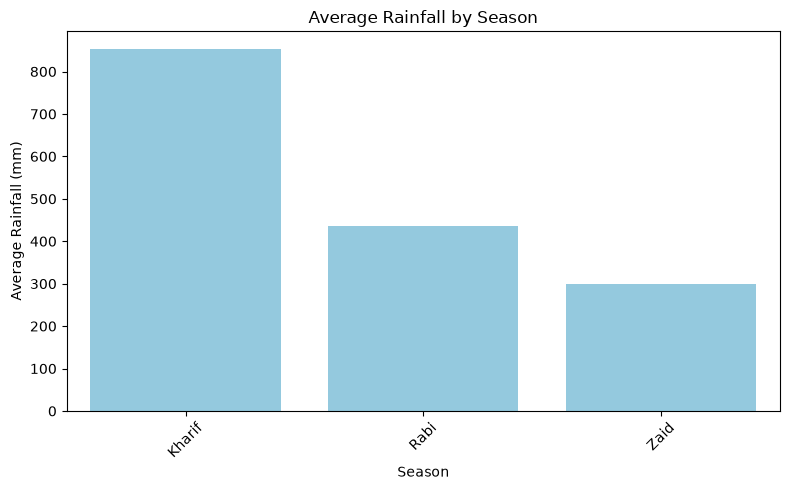

In [81]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=rainfall.index,
    y=rainfall.values,
    color='skyblue'
)

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Average Rainfall (mm)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [83]:
temperature = df.groupby('Season')['Avg_Temperature_C'].mean()

print(temperature)

Season
Kharif    28.455750
Rabi      23.492650
Zaid      31.042088
Name: Avg_Temperature_C, dtype: float64


In [84]:
temperature = (
    df.groupby('Season')['Avg_Temperature_C']
    .mean()
    .round(2)
)

print(temperature)

Season
Kharif    28.46
Rabi      23.49
Zaid      31.04
Name: Avg_Temperature_C, dtype: float64


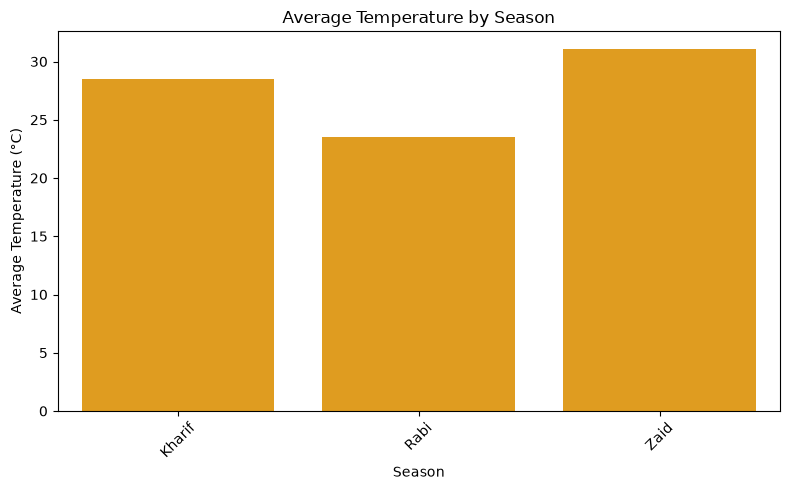

In [85]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=temperature.index,
    y=temperature.values,
    color='orange'
)

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [86]:
humidity = df.groupby('Season')['Humidity_pct'].mean()

print(humidity)

Season
Kharif    71.806708
Rabi      57.909697
Zaid      52.012121
Name: Humidity_pct, dtype: float64


In [87]:
humidity = (
    df.groupby('Season')['Humidity_pct']
    .mean()
    .round(2)
)

print(humidity)



Season
Kharif    71.81
Rabi      57.91
Zaid      52.01
Name: Humidity_pct, dtype: float64


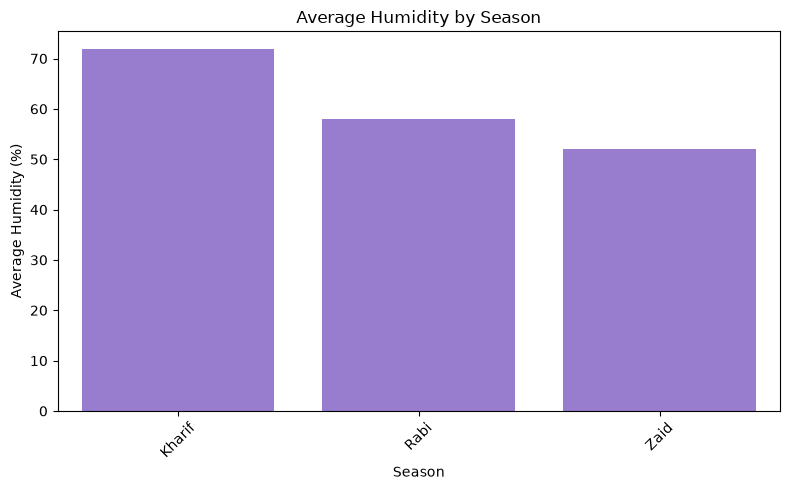

In [88]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=humidity.index,
    y=humidity.values,
    color='mediumpurple'
)

plt.title("Average Humidity by Season")
plt.xlabel("Season")
plt.ylabel("Average Humidity (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



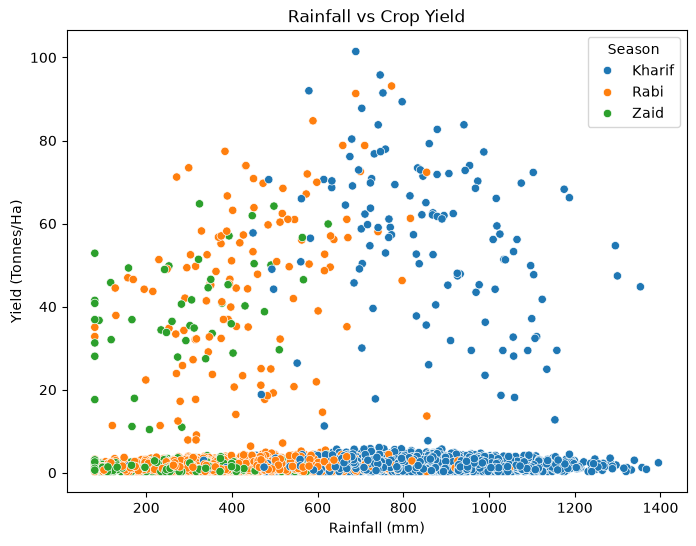

In [89]:
#Rainfall vs Yield
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [90]:
correlation = df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha'])

print("Correlation:", correlation)

Correlation: 0.03085301698272097


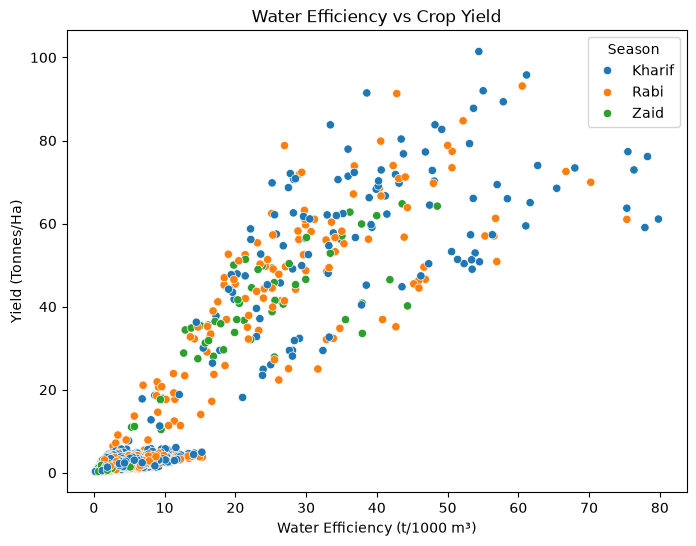

In [91]:
#Water Efficiency vs Yield
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Water_Efficiency_t_per_1000m3',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Water Efficiency vs Crop Yield")
plt.xlabel("Water Efficiency (t/1000 m³)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [92]:
correlation = df['Water_Efficiency_t_per_1000m3'].corr(
    df['Yield_Tonnes_Ha']
)

print("Correlation:", correlation)

Correlation: 0.915437939063249


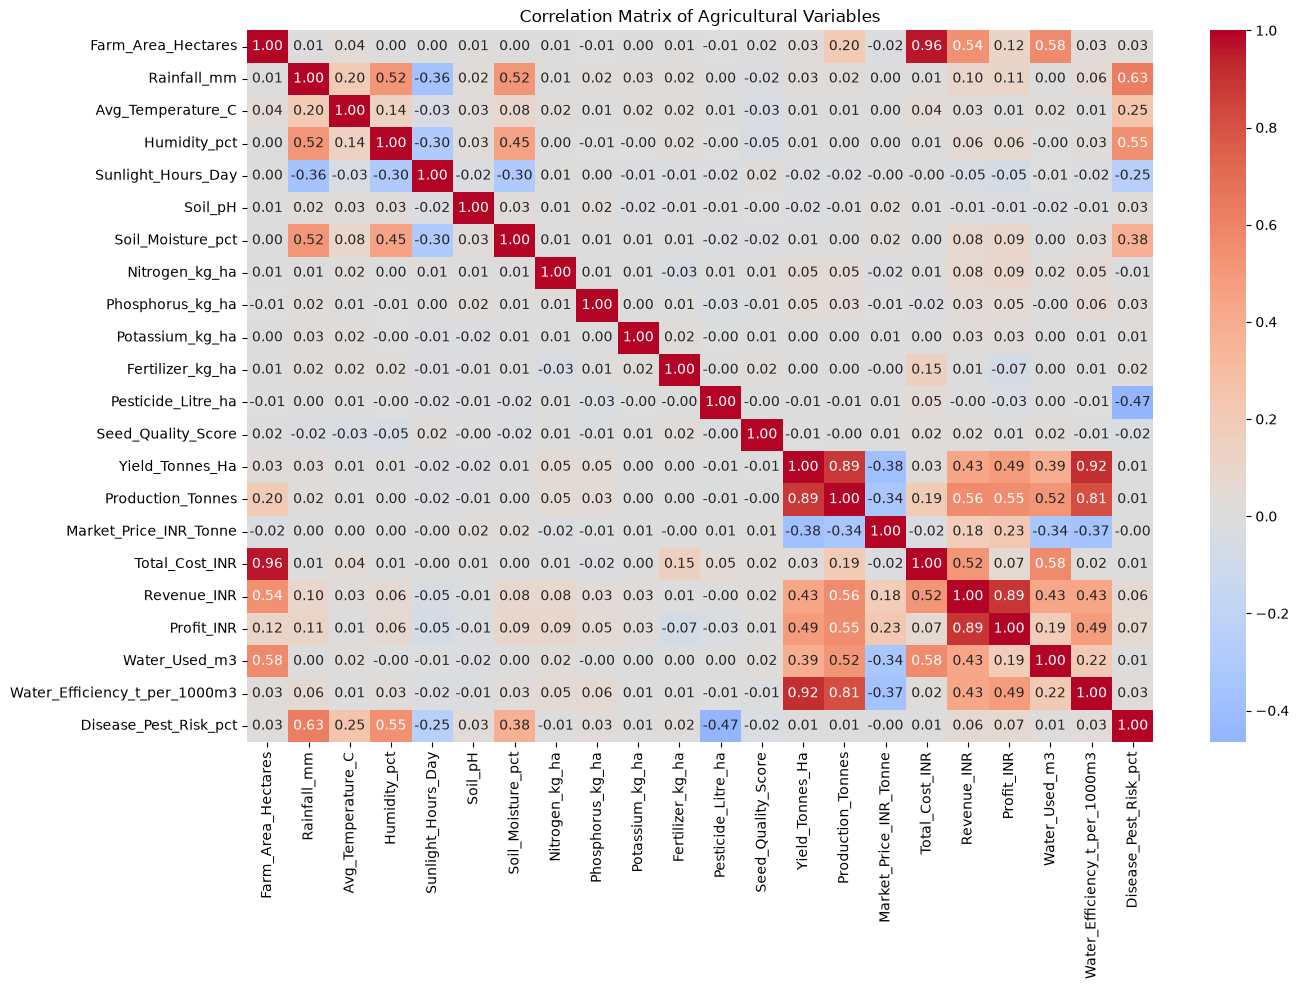

In [93]:
#Find Variables Strongly Related to Yield
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_data = df.select_dtypes(include=np.number)

correlation = numeric_data.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f'
)

plt.title("Correlation Matrix of Agricultural Variables")
plt.tight_layout()
plt.show()

In [94]:
numeric_data = df.select_dtypes(include=np.number)

In [95]:
print(df[['Water_Efficiency_t_per_1000m3', 'Yield_Tonnes_Ha']].corr())


                               Water_Efficiency_t_per_1000m3  Yield_Tonnes_Ha
Water_Efficiency_t_per_1000m3                       1.000000         0.915438
Yield_Tonnes_Ha                                     0.915438         1.000000


In [96]:
#Find Variables Strongly Related to Yield
yield_corr = correlation['Yield_Tonnes_Ha'].sort_values(
    ascending=False
)

print(yield_corr)


Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Profit_INR                       0.489822
Revenue_INR                      0.433648
Water_Used_m3                    0.388653
Nitrogen_kg_ha                   0.053867
Phosphorus_kg_ha                 0.047821
Rainfall_mm                      0.030853
Total_Cost_INR                   0.030814
Farm_Area_Hectares               0.030188
Disease_Pest_Risk_pct            0.013490
Humidity_pct                     0.011277
Soil_Moisture_pct                0.010210
Avg_Temperature_C                0.009349
Potassium_kg_ha                  0.003836
Fertilizer_kg_ha                 0.000562
Seed_Quality_Score              -0.006737
Pesticide_Litre_ha              -0.007650
Sunlight_Hours_Day              -0.015362
Soil_pH                         -0.020664
Market_Price_INR_Tonne          -0.384307
Name: Yield_Tonnes_Ha, dtype: float64


In [97]:
yield_corr = correlation['Yield_Tonnes_Ha'].drop(
    'Yield_Tonnes_Ha'
).sort_values(ascending=False)

print(yield_corr)


Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Profit_INR                       0.489822
Revenue_INR                      0.433648
Water_Used_m3                    0.388653
Nitrogen_kg_ha                   0.053867
Phosphorus_kg_ha                 0.047821
Rainfall_mm                      0.030853
Total_Cost_INR                   0.030814
Farm_Area_Hectares               0.030188
Disease_Pest_Risk_pct            0.013490
Humidity_pct                     0.011277
Soil_Moisture_pct                0.010210
Avg_Temperature_C                0.009349
Potassium_kg_ha                  0.003836
Fertilizer_kg_ha                 0.000562
Seed_Quality_Score              -0.006737
Pesticide_Litre_ha              -0.007650
Sunlight_Hours_Day              -0.015362
Soil_pH                         -0.020664
Market_Price_INR_Tonne          -0.384307
Name: Yield_Tonnes_Ha, dtype: float64


In [98]:
print("Top positive correlations:")
print(yield_corr.head(5))

print("\nTop negative correlations:")
print(yield_corr.tail(5))


Top positive correlations:
Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Profit_INR                       0.489822
Revenue_INR                      0.433648
Water_Used_m3                    0.388653
Name: Yield_Tonnes_Ha, dtype: float64

Top negative correlations:
Seed_Quality_Score       -0.006737
Pesticide_Litre_ha       -0.007650
Sunlight_Hours_Day       -0.015362
Soil_pH                  -0.020664
Market_Price_INR_Tonne   -0.384307
Name: Yield_Tonnes_Ha, dtype: float64


In [99]:
#Statistical Analysis
kharif = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']


In [100]:
print("Kharif:", len(kharif))
print("Rabi:", len(rabi))
print("Zaid:", len(zaid))


Kharif: 1774
Rabi: 1619
Zaid: 594


In [101]:
print("Kharif average:", kharif.mean())
print("Rabi average:", rabi.mean())
print("Zaid average:", zaid.mean())


Kharif average: 5.654136955291455
Rabi average: 5.054190118824265
Zaid average: 4.665942275042444


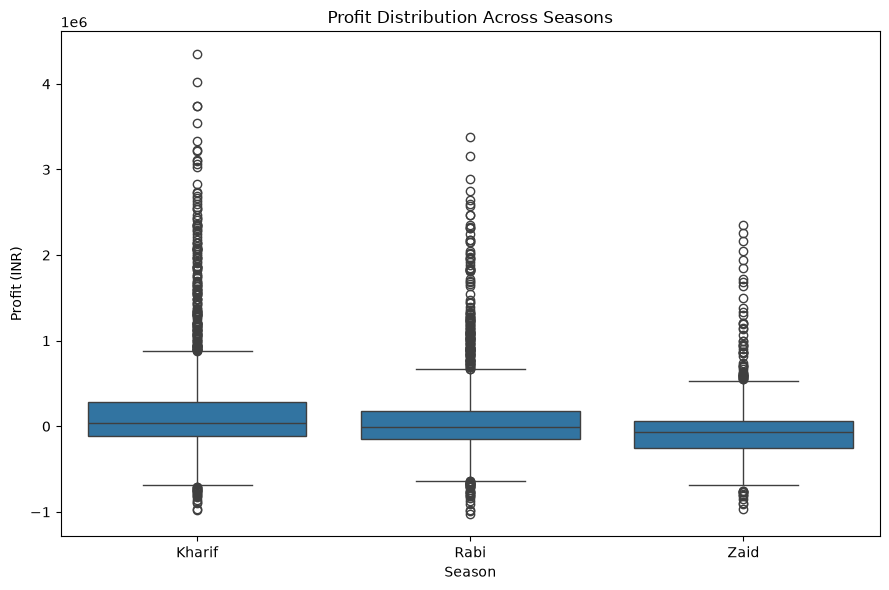

In [102]:
#Seasonal Profit Distribution
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='Season',
    y='Profit_INR'
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()


In [103]:
print(
    df.groupby('Season')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)


Season
Kharif    179542.735626
Rabi       87481.985794
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


In [104]:
#Disease/Pest Risk Analysis
print(df['Disease_Pest_Risk_pct'].value_counts())


Disease_Pest_Risk_pct
42.7    21
43.9    19
52.1    18
48.8    18
55.9    18
        ..
21.5     1
28.7     1
13.8     1
78.8     1
73.3     1
Name: count, Length: 597, dtype: int64


In [105]:
print(df['Disease_Pest_Risk_pct'].describe())


count    4000.000000
mean       46.365875
std        12.424417
min         5.000000
25%        37.300000
50%        46.400000
75%        54.900000
max        88.900000
Name: Disease_Pest_Risk_pct, dtype: float64


In [106]:
df['Risk_Level'] = pd.cut(
    df['Disease_Pest_Risk_pct'],
    bins=[0, 33, 66, 100],
    labels=['Low', 'Medium', 'High']
)

print(df['Risk_Level'].value_counts())


Risk_Level
Medium    3164
Low        597
High       239
Name: count, dtype: int64


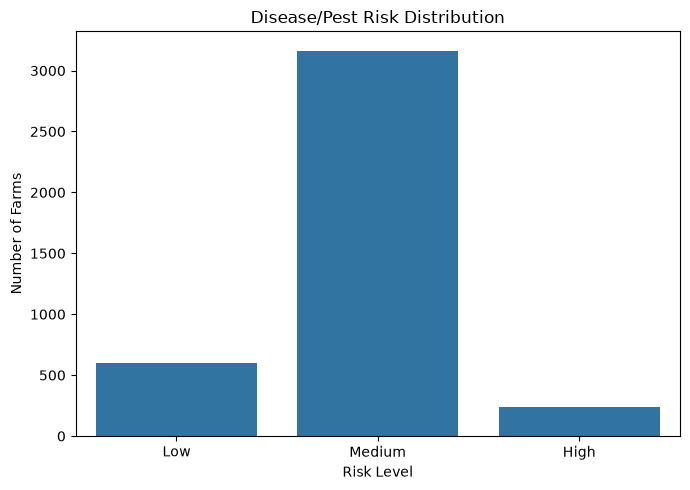

In [107]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Risk_Level'
)

plt.title("Disease/Pest Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.show()


In [108]:
#Regional Analysis
region_performance = df.groupby('State').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).sort_values(
    'Profit_INR',
    ascending=False
)

print(region_performance)


                Yield_Tonnes_Ha     Profit_INR  Water_Efficiency_t_per_1000m3
State                                                                        
Punjab                 6.121116  136025.636364                       5.621700
Maharashtra            5.030333  135428.855469                       5.284379
Karnataka              5.734493  119422.335378                       5.562389
Tamil Nadu             4.901247  117744.748454                       5.305066
Gujarat                5.699586  117568.235656                       5.578648
Telangana              5.076810  108829.616279                       5.464866
Madhya Pradesh         5.029654   86840.756539                       5.266622
Andhra Pradesh         4.650781   73453.527410                       5.031427


In [109]:
region_performance = df.groupby('State').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).sort_values(
    'Profit_INR',
    ascending=False
).round(2)

print(region_performance)


                Yield_Tonnes_Ha  Profit_INR  Water_Efficiency_t_per_1000m3
State                                                                     
Punjab                     6.12   136025.64                           5.62
Maharashtra                5.03   135428.86                           5.28
Karnataka                  5.73   119422.34                           5.56
Tamil Nadu                 4.90   117744.75                           5.31
Gujarat                    5.70   117568.24                           5.58
Telangana                  5.08   108829.62                           5.46
Madhya Pradesh             5.03    86840.76                           5.27
Andhra Pradesh             4.65    73453.53                           5.03


In [110]:
district_performance = df.groupby('District').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).sort_values(
    'Profit_INR',
    ascending=False
).round(2)

print(district_performance)


          Yield_Tonnes_Ha  Profit_INR  Water_Efficiency_t_per_1000m3
District                                                            
Warangal             5.55   166449.96                           5.86
Nalgonda             5.83   131125.84                           5.56
Raichur              4.98   125172.70                           5.31
Rajkot               6.04   120054.06                           5.68
Guntur               5.50   116411.42                           5.75
Erode                4.21   102079.57                           4.46
Nashik               4.88    94910.17                           5.02
Indore               4.88    90421.34                           5.04
Ludhiana             5.85    87590.83                           5.80
Krishna              4.87    78240.90                           5.30


In [111]:
#Create a Performance Summary Table
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

season_summary


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,
Kharif,5.65,46.41,711271.84,531729.10,179542.74,6105.02,5.90
Rabi,5.05,41.33,601301.59,513819.61,87481.99,5846.76,5.16
Zaid,4.67,38.89,519171.90,543976.73,-24804.82,6419.89,4.41


In [112]:
#Calculate Profit Margin
df['Profit_Margin_pct'] = (
    df['Profit_INR'] /
    df['Revenue_INR']
) * 100


In [113]:
print(df[['Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']].head())


   Revenue_INR  Profit_INR  Profit_Margin_pct
0        30810      -11852         -38.468030
1        40401     -451950       -1118.660429
2       190466     -124744         -65.494104
3       200740      -95704         -47.675600
4       193607     -144352         -74.559288


In [114]:
season_margin = (
    df.groupby('Season')['Profit_Margin_pct']
    .mean()
    .round(2)
)

print(season_margin)


Season
Kharif   -38.55
Rabi     -44.46
Zaid     -69.35
Name: Profit_Margin_pct, dtype: float64


Season
Kharif   -38.55
Rabi     -44.46
Zaid     -69.35
Name: Profit_Margin_pct, dtype: float64


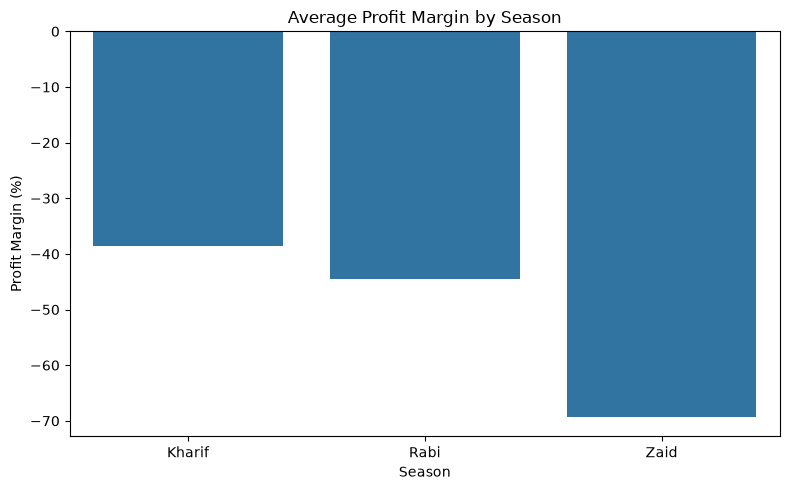

In [116]:
# Calculate average profit margin by season
profit_margin = (
    df.groupby('Season')['Profit_Margin_pct']
    .mean()
    .round(2)
)

# Display values
print(profit_margin)

# Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    x=profit_margin.index,
    y=profit_margin.values
)

plt.title("Average Profit Margin by Season")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

In [120]:
#Identify Top Performing Combinations
combination = df.groupby(
    ['Season', 'Crop', 'Irrigation_Method']
).agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).reset_index()

print(combination)



    Season       Crop Irrigation_Method  Yield_Tonnes_Ha    Profit_INR  \
0   Kharif     Chilli              Drip         1.931000  1.192769e+06   
1   Kharif     Chilli             Flood         1.737091  9.581261e+05   
2   Kharif     Chilli           Rainfed         1.523333  8.331547e+05   
3   Kharif     Chilli         Sprinkler         1.697576  7.632974e+05   
4   Kharif     Cotton              Drip         1.570000  3.210311e+05   
..     ...        ...               ...              ...           ...   
91    Zaid  Sugarcane         Sprinkler        40.102143  6.378727e+05   
92    Zaid      Wheat              Drip         2.084737 -1.416178e+05   
93    Zaid      Wheat             Flood         1.502800 -2.711585e+05   
94    Zaid      Wheat           Rainfed         1.618000 -1.525939e+05   
95    Zaid      Wheat         Sprinkler         1.937500 -1.961382e+05   

    Water_Efficiency_t_per_1000m3  
0                        3.649840  
1                        2.197393  
2  

In [121]:
combination = combination.sort_values(
    'Profit_INR',
    ascending=False
)

print(combination)


    Season       Crop Irrigation_Method  Yield_Tonnes_Ha    Profit_INR  \
24  Kharif  Sugarcane              Drip        62.864412  1.361630e+06   
0   Kharif     Chilli              Drip         1.931000  1.192769e+06   
25  Kharif  Sugarcane             Flood        54.238235  1.014656e+06   
56    Rabi  Sugarcane              Drip        51.393226  9.968643e+05   
1   Kharif     Chilli             Flood         1.737091  9.581261e+05   
..     ...        ...               ...              ...           ...   
78    Zaid      Maize           Rainfed         2.033600 -2.180358e+05   
84    Zaid       Rice              Drip         1.876522 -2.186967e+05   
86    Zaid       Rice           Rainfed         1.883333 -2.321997e+05   
85    Zaid       Rice             Flood         1.748235 -2.577350e+05   
93    Zaid      Wheat             Flood         1.502800 -2.711585e+05   

    Water_Efficiency_t_per_1000m3  
24                      39.751559  
0                        3.649840  
25 

In [122]:
print(combination.head(10))


    Season       Crop Irrigation_Method  Yield_Tonnes_Ha    Profit_INR  \
24  Kharif  Sugarcane              Drip        62.864412  1.361630e+06   
0   Kharif     Chilli              Drip         1.931000  1.192769e+06   
25  Kharif  Sugarcane             Flood        54.238235  1.014656e+06   
56    Rabi  Sugarcane              Drip        51.393226  9.968643e+05   
1   Kharif     Chilli             Flood         1.737091  9.581261e+05   
59    Rabi  Sugarcane         Sprinkler        43.663600  8.443894e+05   
2   Kharif     Chilli           Rainfed         1.523333  8.331547e+05   
26  Kharif  Sugarcane           Rainfed        46.797179  7.873503e+05   
32    Rabi     Chilli              Drip         1.688500  7.850840e+05   
88    Zaid  Sugarcane              Drip        44.590000  7.821869e+05   

    Water_Efficiency_t_per_1000m3  
24                      39.751559  
0                        3.649840  
25                      23.887029  
56                      32.764576  
1    

In [ ]:
#Create Final Findings

# Key Findings

1. Kharif demonstrates the highest average agricultural yield.
2. Kharif also records the highest average profitability.
3. Zaid shows comparatively lower profitability.
4. Zaid has relatively high water consumption.
5. Kharif demonstrates strong water-use efficiency.
6. Irrigation performance varies across seasons.
7. Drip irrigation performs strongly in Kharif and Rabi.
8. Water efficiency has a strong relationship with crop yield.
9. Crop performance varies across different seasons.
10. Agricultural performance depends on multiple environmental,
    resource and economic factors.

In [ ]:
#Recommendations

# Recommendations

1. Promote efficient irrigation practices based on seasonal conditions.

2. Improve water-use efficiency, particularly during high-water-demand
   seasons.

3. Investigate the causes of low profitability during Zaid.

4. Select crops according to seasonal and regional suitability.

5. Use historical environmental data to support seasonal crop planning.

6. Monitor fertilizer, pesticide and water utilization.

7. Identify high-performing crop-irrigation combinations.

8. Monitor disease and pest risk during vulnerable seasons.

9. Use data-driven approaches for agricultural resource allocation.

10. Continuously monitor yield, cost, revenue and profitability.

In [123]:
import os

output_path = os.path.expanduser(
    "~/Downloads/cleaned_seasonal_agriculture_dataset.csv"
)

df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print("Saved at:", output_path)


Cleaned dataset saved successfully!
Saved at: C:\Users\samar/Downloads/cleaned_seasonal_agriculture_dataset.csv
